<a href="https://colab.research.google.com/github/Shubham-Sahoo/acceleration-flow-matching/blob/colab/notebooks/ddpm_latent_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!git clone https://github.com/Shubham-Sahoo/acceleration-flow-matching.git

Cloning into 'acceleration-flow-matching'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 73 (delta 31), reused 41 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 317.44 KiB | 3.24 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [2]:
# Then change your save path:
save_path = '/content/drive/MyDrive/ddpm_checkpoints/'
import os
os.makedirs(save_path, exist_ok=True)

In [3]:
import sys
sys.path.append("/content/acceleration-flow-matching/src")


In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam
from models import LatentViT
from data_loader import train_dataset
from vae import SpatialVae
from tqdm import tqdm
from diffusion import DDPMSpatialLatent
from utils import visualize_samples
from torch.utils.data import DataLoader

In [5]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

In [6]:
def train_ddpm(model_sampler: DDPMSpatialLatent, train_loader, device='cuda', epochs=5, lr=1e-4):
    optimizer = Adam(model_sampler.model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    num_steps = 1000
    betas = torch.linspace(0.0001, 0.02, num_steps, device=device)
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    sqrt_alpha_bars = torch.sqrt(alpha_bars)
    sqrt_1_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

    model_sampler.model.train()

    for epoch in range(epochs):
        total_loss = 0
        progress_bar = tqdm(train_loader, desc=f"DDPM Epoch {epoch+1}/{epochs}")

        for batch_idx, (x, y) in enumerate(progress_bar):

            loss, _ = model_sampler.forward_loss(x, y, num_steps, criterion)

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model_sampler.model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1} - DDPM Loss: {avg_loss:.6f}\n")

        if (epoch+1) % 10 == 1:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_sampler.model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'{save_path}checkpoint_epoch_{epoch+1}.pth')
            print(f"✓ Saved checkpoint to Drive: epoch {epoch+1}, loss={avg_loss:.6f}")

    return model_sampler.model

In [9]:
device = 'cuda'
model = LatentViT(latent_channels=16, embed_dim=192, depth=12, num_heads=3)
model.load_state_dict(torch.load('/content/acceleration-flow-matching/ddpm_latent_model_30_10.pth', map_location=torch.device('cuda'), weights_only=True))
model = model.to(device)

vae = SpatialVae(in_channels=1)
vae.load_state_dict(torch.load('/content/acceleration-flow-matching/spatial_vae_mnist.pth', map_location=torch.device('cuda'), weights_only=True))
vae = vae.to(device)

model_ddpm = DDPMSpatialLatent(model, vae=vae, device=device)


In [23]:
model = train_ddpm(model_ddpm, train_loader, device=device, epochs=50, lr=5e-5)

DDPM Epoch 1/50: 100%|██████████| 235/235 [01:35<00:00,  2.46it/s, loss=0.229]


Epoch 1 - DDPM Loss: 0.272850

✓ Saved checkpoint to Drive: epoch 1, loss=0.272850


DDPM Epoch 2/50: 100%|██████████| 235/235 [01:34<00:00,  2.48it/s, loss=0.308]


Epoch 2 - DDPM Loss: 0.273553



DDPM Epoch 3/50: 100%|██████████| 235/235 [01:34<00:00,  2.48it/s, loss=0.216]


...

Epoch 48 - DDPM Loss: 0.270529



DDPM Epoch 49/50: 100%|██████████| 235/235 [01:34<00:00,  2.48it/s, loss=0.308]


Epoch 49 - DDPM Loss: 0.270494



DDPM Epoch 50/50: 100%|██████████| 235/235 [01:34<00:00,  2.49it/s, loss=0.271]

Epoch 50 - DDPM Loss: 0.271721



In [26]:
torch.save(model.state_dict(), 'ddpm_latent_model_150.pth')
print("✓ Model saved to ddpm_latent_model_150.pth")

✓ Model saved to ddpm_latent_model_150.pth


DDPM: 100%|██████████| 1000/1000 [00:09<00:00, 103.57it/s]


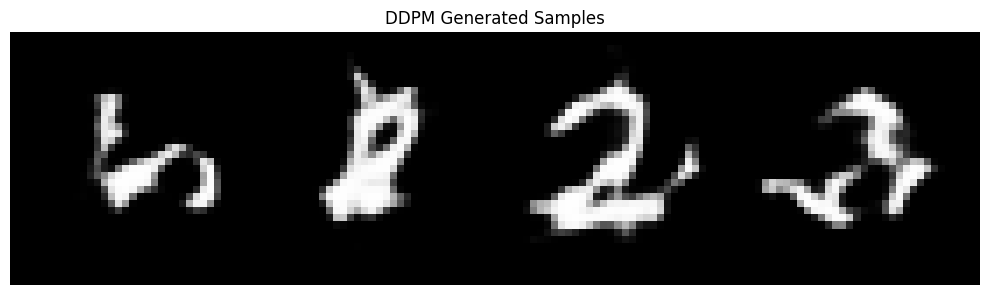

In [34]:
sampler = model_ddpm


# Cell 4: Test and Benchmark

# Generate samples
z_noise = torch.randn(4, 16, 8, 8, device=device)
x_samples = sampler.sample(z_noise, torch.tensor([2]).to(device), t_steps=1000, verbose=True)


# Benchmark
# result = benchmark(sampler, batch_size=4, t_steps=50, num_runs=2)
# print(f"\nDDPM 50 steps: {result['mean_time_s']:.2f}s ± {result['std_time_s']:.2f}s")

# # Visualize
visualize_samples(x_samples, title="DDPM Generated Samples")

✓ Model loaded to ddpm_model.pth
